In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# gradient descent using exact gradients, loops, and stopping when abs(loss_new - loss_old) < tol

def f(x, phi): # dont need to make a separate g function, phi: (2, 1)
    X = np.column_stack([np.ones_like(x), x]) # (3, 2)
    y = X @ phi 
    return y

print(1)

def g_inverse(x, theta):
    y = (x - theta[0])/theta[1]
    return y

def compute_loss(x, y, phi):
    loss = np.sum((f(x, phi) - y)**2)
    return loss

def grad_descent(x, y, phi):
    eta = 0.01
    tol = 0.00001
    new_phi = phi.copy() # (2, 1)
    old_loss = tol
    new_loss = tol + 1
    count = 0
    while abs(new_loss - old_loss) > tol:
        count += 1
        old_loss = new_loss
        X = np.column_stack([np.ones_like(x), x]) # (3, 2)
        errors = f(x, new_phi) - y # (3, 1)
        grad = 2*X.T @ errors # (2, 1)
        new_phi -= eta*grad # (2, 1)
        new_loss = compute_loss(x, y, new_phi)
    return new_phi, count

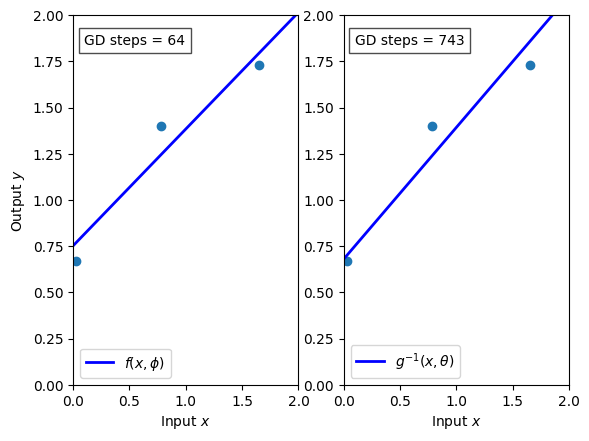

In [4]:
x = np.array([0.03, 0.78, 1.65])
y = np.array([0.67, 1.40, 1.73])

phi = np.random.randn(2)
theta = phi.copy()

phi, fcount = grad_descent(x, y, phi)
theta, gcount = grad_descent(y, x, theta)

# testing inference
fig, ax = plt.subplots(1, 2)
for i in range(2):
    ax[i].scatter(x, y)
    ax[i].set_xlim([0, 2])
    ax[i].set_ylim([0, 2])
    ax[i].set_xlabel('Input $x$')
ax[0].set_ylabel('Output $y$')

# draw lines
x_line = np.arange(0, 2, 0.01)
y_line0 = f(x_line, phi)
y_line1 = g_inverse(x_line, theta)
ax[0].plot(x_line, y_line0, 'b-', lw=2, label=r'$f(x, \phi)$')
ax[0].legend()
ax[0].text(
    0.05, 0.95,
    f'GD steps = {fcount}',
    transform=ax[0].transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.7)
)
ax[1].plot(x_line, y_line1, 'b-', lw=2, label=r'$g^{-1}(x, \theta)$')
ax[1].legend()
ax[1].text(
    0.05, 0.95,
    f'GD steps = {gcount}',
    transform=ax[1].transAxes,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', alpha=0.7)
)
plt.show()
